In [30]:
import geopandas as gpd
import pandas as pd
import numpy as np
import requests
from dep_tools.grids import PACIFIC_EPSG
from fiona.io import ZipMemoryFile
from odc.geo.geom import Geometry
from odc.geo.xr import mask
from odc.stac import load
from pystac.client import Client
from xarray import DataArray, Dataset

In [31]:
site = "vunidogoloa_ra_1" 

In [32]:
# aoi = gpd.read_file("priority_1_sites/subsample_sites/"f"{site}.geojson")

In [33]:
aoi = gpd.read_file("potential_sites/"f"{site}.geojson")

In [34]:
bbox = aoi.to_crs("EPSG:4326")

In [35]:
bounds_df = bbox.bounds
bounds_df

,minx,miny,maxx,maxy
0,177.997176,-17.374918,178.172061,-17.297696


In [36]:
values_array = bounds_df.values
flat_array = values_array.flatten()
bbox_int_list = flat_array.tolist()
bbox_tuple = tuple(bbox_int_list)

In [37]:
bbox = Geometry(bbox.geometry.values[0], crs=bbox.crs)

In [38]:
# bbox.explore()

In [39]:
# Get some seagrass data for the area
client = Client.open("https://stac.digitalearthpacific.org")
items = client.search(
    collections=["dep_s2_seagrass"],
    intersects=bbox.json
).item_collection()

print(f"Found {len(items)} items")

Found 8 items


In [40]:
data = load(
    items,
    bbox=bbox_tuple,
    bands=["seagrass"],
    crs=PACIFIC_EPSG,  # 
    resolution=10,  # Change to 10 for full resolution,
    chunks={"x": 2048, "y": 2048}
)

# Convert data to 0 and 1, where 

data = data.seagrass != 255

data

<xarray.DataArray 'seagrass' (time: 8, y: 896, x: 1947)> Size: 14MB
dask.array<ne, shape=(8, 896, 1947), dtype=bool, chunksize=(1, 896, 1947), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 7kB -1.943e+06 -1.943e+06 ... -1.952e+06 -1.952e+06
  * x            (x) float64 16kB 3.117e+06 3.117e+06 ... 3.136e+06 3.136e+06
    spatial_ref  int32 4B 3832
  * time         (time) datetime64[ns] 64B 2017-01-01 2018-01-01 ... 2024-01-01

In [41]:
def xarray_calculate_area(
    data: Dataset | DataArray,
    geom: Geometry,
    variable: str | None = None,
    value: int | float | None = None,
) -> float:
    # Work with a dataarray, not a dataset, so it's a singular thing
    if type(data) is not DataArray:
        if variable is None:
            raise ValueError("Variable must be specified when data is a Dataset.")
        data = data[variable]

    # Only select a specific value. This will convert to float, with nans
    if value is not None:
        data = data.where(data == value)

    # Mask out regions outsize the geometry
    masked = mask(data, geom.to_crs(data.odc.crs))

    # Count all the non-nan cells, and multiply by area
    count = float(masked.notnull().sum().values)
    one_pixel_area = abs(
        masked.odc.geobox.resolution.x * masked.odc.geobox.resolution.y
    )

    return float(count) * one_pixel_area

In [42]:
bbox.explore()

In [43]:
# Run the xarray_calculate_area per time step
results = []
for time in data.time:
    da = data.sel(time=time)
    area_m2 = xarray_calculate_area(da, bbox, variable="seagrass", value=1)
    # Year, in YYYY, area in m2, area in km2
    results.append({
        "time": pd.to_datetime(time.values).year,
        # "area_m2": area_m2,
        "seagrass": area_m2 / 10000
    })

df = pd.DataFrame(results)
# df

In [44]:
# Keep only the rows where year is NOT 2017
df = df[df['time'] != 2017]

# Reset the index so it starts at 0, 1, 2... again
df = df.reset_index(drop=True)

df

,time,seagrass
0,2018,5731.96
1,2019,5522.83
2,2020,5512.25
3,2021,5675.85
4,2022,5113.52
5,2023,5237.99
6,2024,5267.68


<Axes: xlabel='time'>

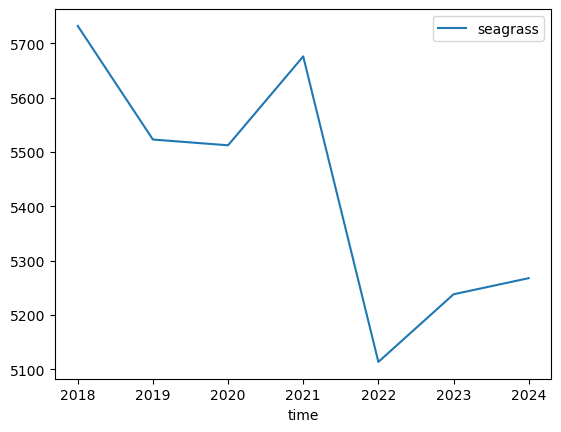

In [45]:
df = df.set_index('time')
df.plot.line()

In [46]:
data

<xarray.DataArray 'seagrass' (time: 8, y: 896, x: 1947)> Size: 14MB
dask.array<ne, shape=(8, 896, 1947), dtype=bool, chunksize=(1, 896, 1947), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float64 7kB -1.943e+06 -1.943e+06 ... -1.952e+06 -1.952e+06
  * x            (x) float64 16kB 3.117e+06 3.117e+06 ... 3.136e+06 3.136e+06
    spatial_ref  int32 4B 3832
  * time         (time) datetime64[ns] 64B 2017-01-01 2018-01-01 ... 2024-01-01

In [55]:
# def xarray_calculate_seagrass(
#     data: Dataset | DataArray,
#     geom: Geometry,
#     variable: str | None = None,
#     value: int | float | None = None,
# ) -> float:
#     # Work with a dataarray, not a dataset, so it's a singular thing
#     if type(data) is not DataArray:
#         if variable is None:
#             raise ValueError("Variable must be specified when data is a Dataset.")
#         data = data[variable]

#     # Only select a specific value. This will convert to float, with nans
#     if value is not None:
#         data = data.where(data == value)

#     # Mask out regions outsize the geometry
#     masked = mask(data, geom.to_crs(data.odc.crs))

In [48]:

data_filtered = data.where((data == 0) | (data == 1))

In [57]:
print("Unique values in data:", np.unique(data_filtered.values))

Unique values in data: [0. 1.]


In [49]:
# # Run the xarray_calculate_area per time step
# seagrass_xr = []
# for time in data.time:
#     da = data.sel(time=time)
#     seagrass_da = xarray_calculate_seagrass(da, bbox, variable="mangroves", value=1)


In [50]:
# seagrass_da

In [51]:
# import numpy as np
# print("Unique values in data:", np.unique(data.values))

In [52]:
# import numpy as np

# # 1. Convert Boolean to Numeric and handle "No Data"
# # We convert to float so we can use np.nan for transparency.
# # If you have a specific 'no data' value (like -9999), mask it here.
# plot_data = data.astype(float).where(data != -9999) 

# # 2. Plot with discrete bins
# plot_data.plot(
#     col="time",
#     col_wrap=4,
#     # Levels define the boundaries: 
#     # Bin 1 [-0.5 to 0.5] captures 0
#     # Bin 2 [ 0.5 to 1.5] captures 1
#     levels=[-0.5, 0.5, 1.5],
    
#     # Define colors: 0 = "lightgray" (no seagrass), 1 = "forestgreen" (seagrass)
#     colors=["#E0E0E0", "#228B22"], 
    
#     cbar_kwargs={
#         "ticks": [0, 1], 
#         "label": "Seagrass Class",
#         "spacing": "proportional"
#     }
# )

In [61]:
data_filtered.plot.imshow(col=time, levels = [0,1,2], colors="viridis")

ValueError: A 3-dimensional array was passed to imshow(), but there is no dimension that could be color.  At least one dimension must be of size 3 (RGB) or 4 (RGBA), and not given as x or y.

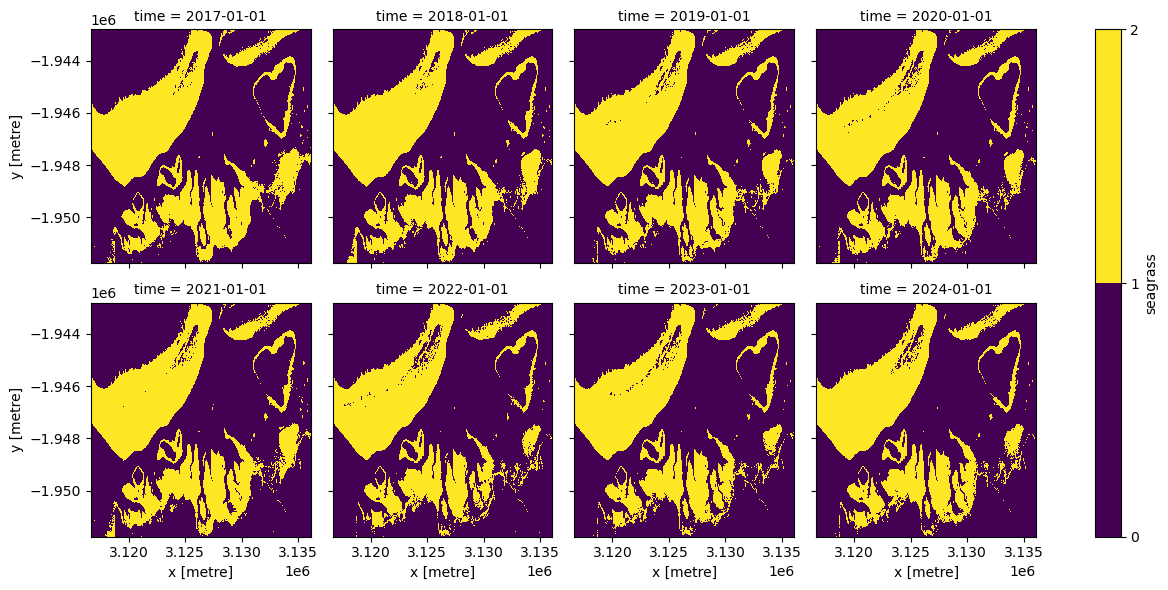

In [58]:
data_filtered.plot.imshow(
    col="time",
    col_wrap=4,
    levels=[0,1,2],
    colors="viridis",
)

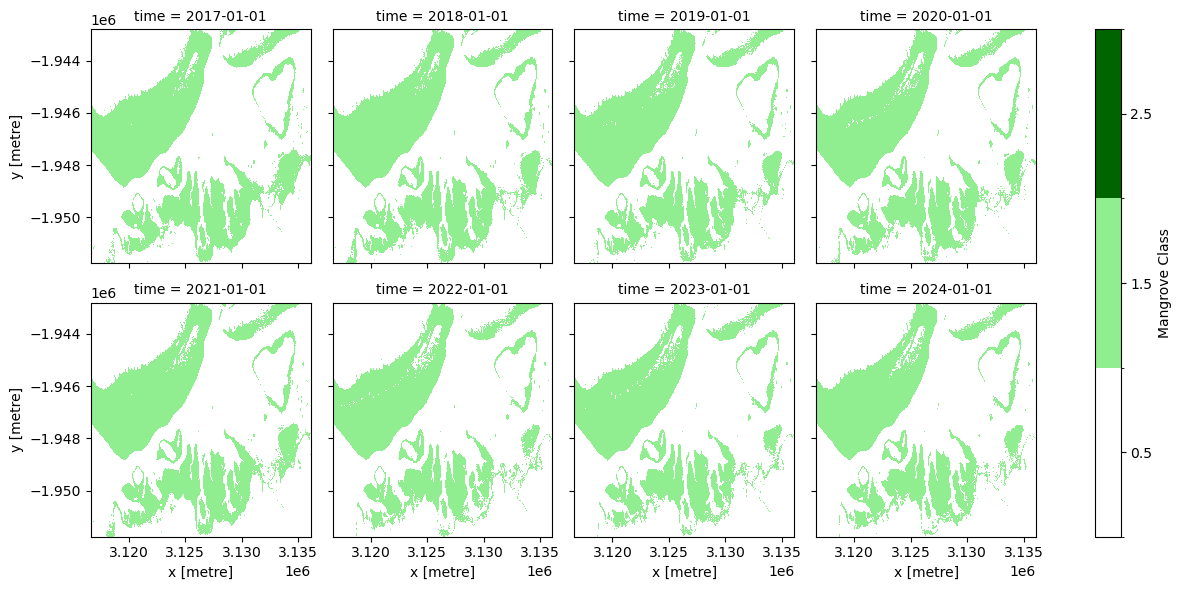

In [54]:
# Use .plot() instead of .plot.imshow() to better handle discrete 'levels'
data_filtered.plot(
    col="time",
    col_wrap=4,
    levels=[0, 1, 2, 3],        # 4 boundaries to create 3 color bins
    colors=["white", "lightgreen", "darkgreen"], # One color for each class (0, 1, 2)
    cbar_kwargs={"ticks": [0.5, 1.5, 2.5], "label": "Mangrove Class"} # Centers labels
)

In [ ]:
# mangroves_2018 = data.isel(time=1)
# mangroves_2018 = mangroves_2018.astype("uint16")
# mangroves_2024 = data.isel(time=7)
# mangroves_2024 = mangroves_2024.astype("uint16")
# mangrove_change_2018_2024 = (mangroves_2024*-2) - mangroves_2018
# # mangrove_change_2018_2024.odc.write_cog("change_detection/mangroves_ammi_change_"f"{site}_2018_2024.tiff")

In [ ]:
# # df = transposed_df
# df.columns.name = None
# df.columns = df.columns.astype(int)
# df.index.name = None
df

In [ ]:
# 1. Move 'time' and 'values' from index to columns
df_reset = df.reset_index()

# 2. Now you can set 'time' as the index
area_df = df_reset.set_index('time')

# 3. Transpose the NEW area_df (not the old df)
transposed_df = area_df.transpose()
transposed_df.index.name = None
transposed_df

In [ ]:
# area_df = df.set_index('time')
transposed_df = df.transpose()
transposed_df.index.name = None
transposed_df

In [ ]:
# # Keep everything from row 1 onwards
# # for rows
# # df = df.iloc[1:]
# ## for columns 
# # df = df.iloc[:, 1:]
# # Optional: Reset index again to start at 0
# df = df.reset_index(drop=True)

# df

In [ ]:
# df_clean

In [ ]:
# df_clean = df.set_index('time')
# df_clean.plot.line()

In [ ]:
# df_clean.to_csv("change_detection/"f"{site}.csv")

In [ ]:
# df.plot(x="ammi_ha", y="ammi_ha", marker="o", title=site, ylim=(0, df["ammi_ha"].max() * 1.1))

In [ ]:
# for r in results:
#     print(f"{r['time']}: {r['ammi_ha']:.2f} km²")

In [ ]:
# df

In [ ]:
# mangrove_change_2018_2024 = data.mangrove.isel(time=7) - data.mangrove.isel(time=1)

In [ ]:
data = data.astype("uint16")

data.odc.write_cog("seagrass_data.tif")

In [ ]:
import matplotlib.pyplot as plt

import numpy as np

# 1. Isolate only Seagrass (1) and No Seagrass (0)
# We use .where to keep 0 and 1. Anything else (like 2, 3, etc.) becomes NaN.
# This removes the "blue block" representing other habitats.
seagrass_data = data.where((data == 0) | (data == 1))

# 2. Plotting with transparency for everything else
seagrass_data.plot(
    col="time",
    col_wrap=4,
    # Define two bins: [-0.5 to 0.5] for 0, and [0.5 to 1.5] for 1
    levels=[-0.5, 0.5, 1.5],
    
    # Colors: 0 = lightgray (No Seagrass), 1 = forestgreen (Seagrass)
    # The 'NaN' values from other habitats will be transparent.
    colors=["#E0E0E0", "#228B22"], 
    
    cbar_kwargs={
        "ticks": [0, 1], 
        "label": "Seagrass Classification"
    }
)

# Optional: Set the tick labels to be descriptive
plt.gcf().axes[-1].set_yticklabels(['No Seagrass', 'Seagrass'])

In [ ]:
import numpy as np

# 1. Isolate only Seagrass (1) and No Seagrass (0)
# We use .where to keep 0 and 1. Anything else (like 2, 3, etc.) becomes NaN.
# This removes the "blue block" representing other habitats.
seagrass_data = data.where((data == 0) | (data == 1))

# 2. Plotting with transparency for everything else
seagrass_data.plot(
    col="time",
    col_wrap=4,
    # Define two bins: [-0.5 to 0.5] for 0, and [0.5 to 1.5] for 1
    levels=[-0.5, 0.5, 1.5],
    
    # Colors: 0 = lightgray (No Seagrass), 1 = forestgreen (Seagrass)
    # The 'NaN' values from other habitats will be transparent.
    colors=["#E0E0E0", "#228B22"], 
    
    cbar_kwargs={
        "ticks": [0, 1], 
        "label": "Seagrass Classification"
    }
)

# Optional: Set the tick labels to be descriptive
plt.gcf().axes[-1].set_yticklabels(['No Seagrass', 'Seagrass'])